# Data Concatenation and Preprocessing

This notebook:
1. Collects all individual session CSVs for each animal
2. Merges them into per-animal datasets
3. Adds preprocessing columns (Date, Outcome, spatial locations)
4. Saves individual animal files
5. Merges all animals into a master dataset

**Animals included:**
- Fiona, Zazu, Sunflower, Tuna, Raven, Knuckles, Salmon, Griffin, Coral, Sonic

## Setup

In [40]:
import os
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [41]:
# Configuration
ANIMAL_LIST = ['Fiona', 'Zazu', 'Sunflower', 'Tuna', 'Raven', 'Knuckles', 'Salmon', 'Griffin', 'Coral', 'Sonic']

BASE_PATH = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data'

# Output directory for merged files
OUTPUT_DIR = os.path.join(BASE_PATH, 'Merged_Data')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Merged_Data


## Helper Functions

In [ ]:
def collect_csv_files(folder_path):
    """
    Recursively find all CSV files in a folder.
    Excludes any files with 'merged' in the name to avoid re-processing merged files.
    
    Args:
        folder_path: Root directory to search
        
    Returns:
        List of full paths to CSV files
    """
    csv_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith('.csv') and 'merged' not in file.lower():
                csv_files.append(os.path.join(root, file))
    return sorted(csv_files)  # Sort for consistent ordering


def read_and_merge_csvs(csv_files, animal_name):
    """
    Read multiple CSV files and concatenate them.
    Extracts session information from filenames.
    
    Args:
        csv_files: List of CSV file paths
        animal_name: Name of animal for metadata
        
    Returns:
        Concatenated DataFrame with all sessions
    """
    data_frames = []
    
    for file_path in csv_files:
        try:
            # Read CSV with low_memory=False to handle mixed types
            df = pd.read_csv(file_path, low_memory=False)
            
            # Extract filename without extension
            filename = os.path.basename(file_path).replace('.csv', '')
            
            # Add session identifier
            df['Session_Filename'] = filename
            
            data_frames.append(df)
            
        except Exception as e:
            print(f"  ⚠️  Error reading {os.path.basename(file_path)}: {e}")
            continue
    
    if not data_frames:
        print(f"  ❌ No valid CSV files found for {animal_name}")
        return None
    
    # Concatenate all dataframes
    merged_df = pd.concat(data_frames, axis=0, ignore_index=True, join='outer')
    
    print(f"  ✓ Merged {len(data_frames)} sessions ({len(merged_df):,} total trials)")
    
    return merged_df


def categorize_location(x, y, tolerance=0.5):
    """
    Categorize spatial location on screen.
    
    Args:
        x: Horizontal coordinate (positive = right, negative = left)
        y: Vertical coordinate (positive = up, negative = down)
        tolerance: Distance from 0 to count as "center" on that axis
        
    Returns:
        String describing location (e.g., 'TopRight', 'CenterLeft')
    """
    # Handle NaN values
    if pd.isna(x) or pd.isna(y):
        return 'LOCATION_NEEDED'
    
    # Determine horizontal position
    if abs(x) < tolerance:
        horizontal = 'Center'
    elif x > 0:
        horizontal = 'Right'
    else:
        horizontal = 'Left'
    
    # Determine vertical position
    if abs(y) < tolerance:
        vertical = 'Center'
    elif y > 0:
        vertical = 'Top'
    else:
        vertical = 'Bottom'
    
    # Combine to create location label
    if horizontal == 'Center' and vertical == 'Center':
        return 'LOCATION_NEEDED'
    elif horizontal == 'Center':
        return f'{vertical}Center'
    elif vertical == 'Center':
        return f'{horizontal}Center'
    else:
        return f'{vertical}{horizontal}'


def preprocess_dataframe(df):
    """
    Apply all preprocessing steps to a merged dataframe.
    
    Steps:
    1. Remove SkippedFrameTimeInfo columns
    2. Create Date column from Month/Day/Year
    3. Create Outcome column from Reward (1=Rewarded, 0=Unrewarded)
    4. Add spatial location categorization for both targets
    5. Create Session_ID from date + filename
    
    Args:
        df: Raw merged dataframe
        
    Returns:
        Preprocessed dataframe
    """
    print("  Preprocessing...")
    
    # 1. Remove SkippedFrameTimeInfo columns (these are massive and not useful)
    df = df.loc[:, ~df.columns.str.contains('SkippedFrameTimeInfo', case=False)]
    
    # 2. Create Date column
    if all(col in df.columns for col in ['Month', 'Day', 'Year']):
        df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']]).dt.strftime('%Y-%m-%d')
    
    # 3. Create Outcome column (binary reward)
    if 'Reward' in df.columns:
        df['Outcome'] = df['Reward'].apply(lambda x: 1 if x == 'Rewarded' else 0)
    
    # 4. Add spatial location categorization
    if 'Target1_x' in df.columns and 'Target1_y' in df.columns:
        df['Target1_location'] = df.apply(
            lambda row: categorize_location(row['Target1_x'], row['Target1_y']), 
            axis=1
        )
    
    if 'Target2_x' in df.columns and 'Target2_y' in df.columns:
        df['Target2_location'] = df.apply(
            lambda row: categorize_location(row['Target2_x'], row['Target2_y']), 
            axis=1
        )
    
    # 5. Create Session_ID (unique identifier for each session)
    if 'Date' in df.columns and 'Session_Filename' in df.columns:
        df['Session_ID'] = df['Date'] + '_' + df['Session_Filename']
    

    # Add this section to the preprocess_dataframe() function, after step 5

    # 6. Calculate PhysicalChoice (which physical location was actually touched)
    if 'StimuliChosen' in df.columns and 'Target1_location' in df.columns and 'Target2_location' in df.columns:
        # TargetA = high prob option = Target1
        # TargetB = low prob option = Target2
        df['PhysicalChoice'] = df.apply(
            lambda row: row['Target1_location'] if row['StimuliChosen'] == 'TargetA' 
            else row['Target2_location'] if row['StimuliChosen'] == 'TargetB'
            else None,
            axis=1
        )
    
    # 7. Calculate PhysicalSwitch (whether they switched physical locations from previous trial)
    if 'PhysicalChoice' in df.columns and 'Session_ID' in df.columns:
        # Sort by session and trial to ensure proper ordering
        if 'Trial' in df.columns:
            df = df.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
        
        # Group by session and get previous trial's physical choice
        df['PrevPhysicalChoice'] = df.groupby('Session_ID')['PhysicalChoice'].shift(1)
        
        # PhysicalSwitch = 1 if location changed, 0 if stayed, NaN for first trial of session
        df['PhysicalSwitch'] = (df['PhysicalChoice'] != df['PrevPhysicalChoice']).astype(float)
        
        # Set first trial of each session to NaN (no previous trial to compare)
        first_trials = df.groupby('Session_ID').head(1).index
        df.loc[first_trials, 'PhysicalSwitch'] = np.nan

    # 8. Create prob_Condition column (e.g., "90-10", "80-20")
    if 'ProbReward' in df.columns and 'Session_ID' in df.columns:
        print("  Creating prob_Condition column...")
        
        # Initialize column
        df['prob_Condition'] = None
        
        for session_id in df['Session_ID'].unique():
            # Get the rows for the current session_id
            session_rows = df[df['Session_ID'] == session_id]
            
            # Find the min and max values of 'ProbReward'
            min_prob = session_rows['ProbReward'].min()
            max_prob = session_rows['ProbReward'].max()
            
            # Skip if values are invalid
            if pd.isna(min_prob) or pd.isna(max_prob):
                continue
            
            # Convert to percentage if needed (0.0-1.0 range)
            if max_prob <= 1.0:
                min_prob *= 100
                max_prob *= 100
            
            # Convert to integers
            min_prob = int(min_prob)
            max_prob = int(max_prob)
            
            # Create the prob_Condition string
            prob_condition = f"{max_prob}-{min_prob}"
            
            # Update the prob_Condition column for these rows
            df.loc[df['Session_ID'] == session_id, 'prob_Condition'] = prob_condition


    # 9. Categorize Task_Type based on filename
    if 'Session_Filename' in df.columns:
        def categorize_task(filename):
            """Categorize task type from session filename"""
            if pd.isna(filename):
                return 'Unknown'
            
            filename_str = str(filename).lower()
            
            # Check patterns in priority order
            if 'setchange' in filename_str:
                return 'Reversal_SetChanges'
            elif 'reversal' in filename_str:
                return 'Reversal'
            elif 'where' in filename_str:
                return 'WhereTask'
            elif 'shaping' in filename_str:
                return 'Shaping'
            else:
                return 'WhatTask'
        
        df['Task_Type'] = df['Session_Filename'].apply(categorize_task)


    # Check for any LOCATION_NEEDED flags
    location_needed_count = (
        (df['Target1_location'] == 'LOCATION_NEEDED').sum() + 
        (df['Target2_location'] == 'LOCATION_NEEDED').sum()
    )
    if location_needed_count > 0:
        print(f"  ⚠️  {location_needed_count} trials flagged with LOCATION_NEEDED")
    
    print(f"  ✓ Preprocessing complete")
    
    return df

## Process Each Animal

In [43]:
# Store individual animal dataframes for later merging
animal_dataframes = {}

for animal_name in ANIMAL_LIST:
    print(f"\n{'='*60}")
    print(f"Processing: {animal_name}")
    print(f"{'='*60}")
    
    # Define paths
    animal_folder = os.path.join(BASE_PATH, animal_name, 'Conflict Days')
    
    # Check if folder exists
    if not os.path.exists(animal_folder):
        print(f"⚠️  Folder not found: {animal_folder}")
        print(f"Skipping {animal_name}...")
        continue
    
    # Collect CSV files
    print(f"Collecting CSV files from: {animal_folder}")
    csv_files = collect_csv_files(animal_folder)
    
    if not csv_files:
        print(f"❌ No CSV files found for {animal_name}")
        continue
    
    print(f"Found {len(csv_files)} CSV files")
    
    # Merge CSVs
    merged_df = read_and_merge_csvs(csv_files, animal_name)
    
    if merged_df is None or len(merged_df) == 0:
        print(f"❌ Failed to merge data for {animal_name}")
        continue
    
    # Preprocess
    processed_df = preprocess_dataframe(merged_df)
    
    # Store in dictionary
    animal_dataframes[animal_name] = processed_df
    
    # Save individual animal file
    output_file = os.path.join(OUTPUT_DIR, f'{animal_name}_merged_preprocessed.csv')
    processed_df.to_csv(output_file, index=False)
    print(f"✓ Saved: {output_file}")
    
    # Print summary stats
    print(f"\nSummary for {animal_name}:")
    print(f"  Total trials: {len(processed_df):,}")
    print(f"  Sessions: {processed_df['Session_ID'].nunique() if 'Session_ID' in processed_df.columns else 'N/A'}")
    print(f"  Date range: {processed_df['Date'].min()} to {processed_df['Date'].max()}" if 'Date' in processed_df.columns else "")

print(f"\n{'='*60}")
print(f"Individual animal processing complete!")
print(f"{'='*60}")


Processing: Fiona
Found 138 CSV files
  ✓ Merged 138 sessions (48,500 total trials)
  Preprocessing...
  Creating prob_Condition column...
  ⚠️  3564 trials flagged with LOCATION_NEEDED
  ✓ Preprocessing complete
✓ Saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Merged_Data/Fiona_merged_preprocessed.csv

Summary for Fiona:
  Total trials: 48,500
  Sessions: 138
  Date range: 2021-10-15 to 2024-03-25

Processing: Zazu
Found 248 CSV files
  ✓ Merged 248 sessions (65,892 total trials)
  Preprocessing...
  Creating prob_Condition column...
  ⚠️  484 trials flagged with LOCATION_NEEDED
  ✓ Preprocessing complete
✓ Saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Merged_Data/Zazu_merged_preprocessed.csv

Summary for Zazu:
  Total trials: 65,892
  Sessions: 247
  D

In [44]:
processed_df.Reward.unique()

array(['Rewarded', 'Unrewarded', nan], dtype=object)

In [45]:
# Check for missing Animal_Name values in each animal's data
print("\nChecking for missing Animal_Name values...\n")

for animal_name, df in animal_dataframes.items():
    missing_count = df['Animal_Name'].isna().sum()
    if missing_count > 0:
        print(f"⚠️  {animal_name}: {missing_count} trials missing Animal_Name")
        
        # Show which sessions have missing names
        if 'Session_Filename' in df.columns:
            missing_sessions = df[df['Animal_Name'].isna()]['Session_Filename'].unique()
            print(f"   Affected sessions: {list(missing_sessions)[:5]}")  # Show first 5
    else:
        print(f"✓ {animal_name}: All trials have Animal_Name")


Checking for missing Animal_Name values...

✓ Fiona: All trials have Animal_Name
✓ Zazu: All trials have Animal_Name
✓ Sunflower: All trials have Animal_Name
✓ Tuna: All trials have Animal_Name
⚠️  Raven: 237 trials missing Animal_Name
   Affected sessions: ['20211104_Raven_100%Con_WhereBlocks2.4(1)', '20220106_Raven_100%Con_WhereBlocks3.12(1)']
✓ Knuckles: All trials have Animal_Name
✓ Salmon: All trials have Animal_Name
✓ Griffin: All trials have Animal_Name
✓ Coral: All trials have Animal_Name
⚠️  Sonic: 280 trials missing Animal_Name
   Affected sessions: ['20230606_Sonic_WhereBlockswShaping', '230608_Sonic_VDT_NoInitiation_100%Conflict_WhereBlocks1.1_WithShaping']


In [46]:
# Fill missing Animal_Name values based on which animal's dataframe they're in
print("\nFilling missing Animal_Name values...\n")

for animal_name, df in animal_dataframes.items():
    missing_count = df['Animal_Name'].isna().sum()
    if missing_count > 0:
        print(f"  Filling {missing_count} missing values for {animal_name}")
        animal_dataframes[animal_name]['Animal_Name'] = animal_dataframes[animal_name]['Animal_Name'].fillna(animal_name)

print("\n✓ All Animal_Name values filled")


Filling missing Animal_Name values...

  Filling 237 missing values for Raven
  Filling 280 missing values for Sonic

✓ All Animal_Name values filled


## Merge All Animals into Master Dataset

In [47]:
print(f"\n{'='*60}")
print("Creating master dataset with all animals...")
print(f"{'='*60}\n")

if animal_dataframes:
    # Concatenate all animal dataframes
    master_df = pd.concat(animal_dataframes.values(), axis=0, ignore_index=True, join='outer')
    
    # Save master file
    master_output_file = os.path.join(OUTPUT_DIR, 'Master_All_Animals_Preprocessed.csv')
    master_df.to_csv(master_output_file, index=False)
    
    print(f"✓ Master dataset saved: {master_output_file}")
    print(f"\nMaster Dataset Summary:")
    print(f"  Total animals: {len(animal_dataframes)}")
    print(f"  Total trials: {len(master_df):,}")
    print(f"  Total sessions: {master_df['Session_ID'].nunique() if 'Session_ID' in master_df.columns else 'N/A'}")
    print(f"  Date range: {master_df['Date'].min()} to {master_df['Date'].max()}" if 'Date' in master_df.columns else "")
    print(f"\nTrials per animal:")
    if 'Animal_Name' in master_df.columns:
        for animal in sorted(master_df['Animal_Name'].unique()):
            count = len(master_df[master_df['Animal_Name'] == animal])
            print(f"  {animal}: {count:,} trials")
else:
    print("❌ No animal data to merge!")

print(f"\n{'='*60}")
print("✓ ALL PROCESSING COMPLETE!")
print(f"{'='*60}")


Creating master dataset with all animals...

✓ Master dataset saved: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Merged_Data/Master_All_Animals_Preprocessed.csv

Master Dataset Summary:
  Total animals: 10
  Total trials: 338,861
  Total sessions: 1227
  Date range: 2020-12-15 to 2024-03-25

Trials per animal:
  Coral: 6,715 trials
  Fiona: 48,500 trials
  Griffin: 60,048 trials
  Griffin_Visual_Discrimination_Task_NoInitiation: 710 trials
  Knuckles: 31,317 trials
  Raven: 58,239 trials
  Salmon: 17,473 trials
  Sonic: 20,212 trials
  Sunflower: 24,274 trials
  Tuna: 5,481 trials
  Zazu: 65,892 trials

✓ ALL PROCESSING COMPLETE!


In [48]:
master_df.columns.unique()

Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       'Day', 'Hour', 'Minute', 'Second', 'BehavioralCodes',
       'ObjectStatusRecord', 'RewardRecord', 'VariableChanges', 'CycleRate_1',
       'CycleRate_2', 'Ver', 'Target1_name', 'Target1_x', 'Target1_y',
       'Target1_xsize', 'Target1_ysize', 'Target1_path', 'Target2_name',
       'Target2_x', 'Target2_y', 'Target2_xsize', 'Target2_ysize',
       'Target2_path', 'RewardVolume', 'RewardType', 'BlockLength',
       'RandomValue', 'Block_Prob', 'StimuliChosen', 'ProbReward', 'Reward',
       'Animal_Name', 'Session_Filename', 'CodeTimes_1', 'CodeTimes_2',
       'CodeTimes_3', 'CodeTimes_4', 'CodeNumbers_1', 'CodeNumbers_2',
       'CodeNumbers_3', 'CodeNumbers_4', 'StartTimes', 'EndTimes',
       'reward_dur', 'EyeOffset_1', 'EyeOffset_2', 'Eye2Offset_1',
       'Eye2Offset_2', 'CodeTimes_5', 'CodeTimes_6', 'CodeTimes_7',
       

In [36]:
# Apply prob_Condition to existing master_df
if 'ProbReward' in master_df.columns and 'Session_ID' in master_df.columns:
    print("Creating prob_Condition column...")
    master_df['prob_Condition'] = None
    
    for session_id in master_df['Session_ID'].unique():
        session_rows = master_df[master_df['Session_ID'] == session_id]
        min_prob = session_rows['ProbReward'].min()
        max_prob = session_rows['ProbReward'].max()
        
        if pd.isna(min_prob) or pd.isna(max_prob):
            continue
        
        if max_prob <= 1.0:
            min_prob *= 100
            max_prob *= 100
        
        min_prob = int(min_prob)
        max_prob = int(max_prob)
        prob_condition = f"{max_prob}-{min_prob}"
        
        master_df.loc[master_df['Session_ID'] == session_id, 'prob_Condition'] = prob_condition
    
    print("✓ prob_Condition column created")
    print(f"\nProbability conditions found:")
    print(master_df['prob_Condition'].value_counts())
    
    # Resave
    master_output_file = os.path.join(OUTPUT_DIR, 'Master_All_Animals_Preprocessed.csv')
    master_df.to_csv(master_output_file, index=False)
    print("✓ Master file updated")

Creating prob_Condition column...
✓ prob_Condition column created

Probability conditions found:
80-20      105833
100-0      101555
90-10       52592
100-100      9944
80-80          11
90-90           4
0-0             2
Name: prob_Condition, dtype: int64
✓ Master file updated


In [39]:
# Add Task_Type to existing master_df
if 'Session_Filename' in master_df.columns:
    print("Creating Task_Type column...")
    
    def categorize_task(filename):
        if pd.isna(filename):
            return 'Unknown'
        
        filename_str = str(filename).lower()
        
        if 'setchange' in filename_str:
            return 'Reversal_SetChanges'
        elif 'reversal' in filename_str:
            return 'Reversal'
        elif 'where' in filename_str:
            return 'WhereTask'
        elif 'shaping' in filename_str:
            return 'Shaping'
        else:
            return 'WhatTask'
    
    master_df['Task_Type'] = master_df['Session_Filename'].apply(categorize_task)
    
    print("✓ Task_Type column created")
    print(f"\nTask types found:")
    print(master_df['Task_Type'].value_counts())
    
    # Resave
    master_output_file = os.path.join(OUTPUT_DIR, 'Master_All_Animals_Preprocessed.csv')
    master_df.to_csv(master_output_file, index=False)
    print("✓ Master file updated")

Creating Task_Type column...
✓ Task_Type column created

Task types found:
WhereTask              149110
Reversal               104871
WhatTask                40486
Reversal_SetChanges     34533
Shaping                  9861
Name: Task_Type, dtype: int64
✓ Master file updated


## Verify Data Quality

In [49]:
master_df

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,...,TaskObject2_LocX,TaskObject2_LocY,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2
0,1,1,1,1,1,6,NaN,0.000000e+00,2021,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,2,1,1,6,NaN,6.885500e+04,2021,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,3,1,1,6,NaN,8.553550e+04,2021,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,4,1,1,0,NaN,9.276853e+04,2021,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,5,1,1,6,NaN,1.082510e+05,2021,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338856,488,25,8,1,1,6,NaN,3.257332e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
338857,489,25,9,1,1,6,NaN,3.260148e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
338858,490,25,10,1,1,6,NaN,3.262315e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
338859,491,25,11,1,1,0,NaN,3.264465e+06,2023,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


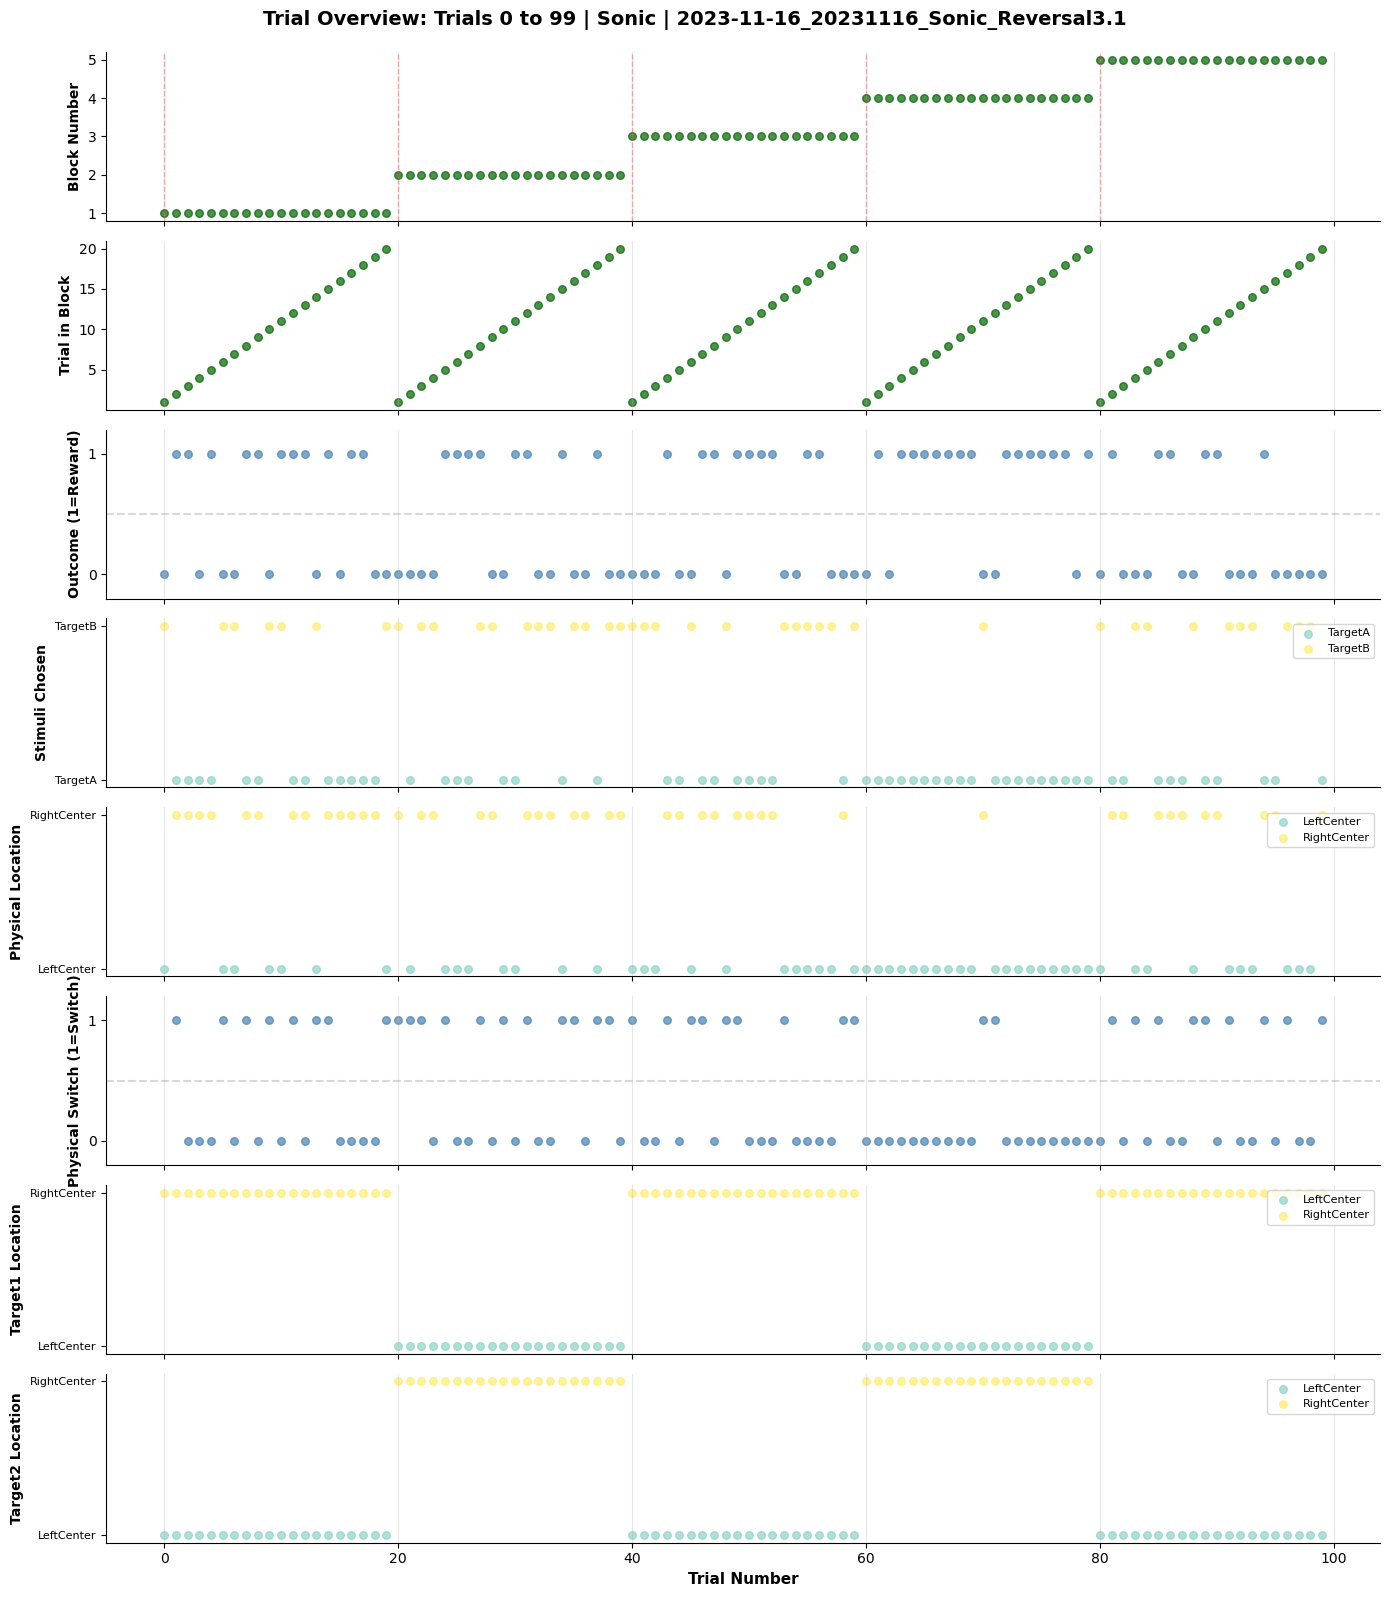


Summary for plotted trials:
  Animal: Sonic
  Date range: 2023-11-16 to 2023-11-16
  Blocks: 1 to 5
  Sessions: 1


In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_trial_overview(df, start_trial=0, n_trials=100, animal=None, session_id=None):
    """
    Create an overview plot showing multiple variables across trials.
    Each variable gets its own subplot as points.
    
    Args:
        df: DataFrame with behavioral data
        start_trial: Starting trial index (default 0)
        n_trials: Number of trials to plot (default 100)
        animal: Optional animal name to filter
        session_id: Optional specific session to plot
    """
    # Filter data if requested
    plot_df = df.copy()
    if animal:
        plot_df = plot_df[plot_df['Animal_Name'] == animal]
    if session_id:
        plot_df = plot_df[plot_df['Session_ID'] == session_id]
    
    # Get the slice of trials
    plot_df = plot_df.iloc[start_trial:start_trial + n_trials].copy()
    
    if len(plot_df) == 0:
        print("No data found for specified filters!")
        return
    
    # Create trial numbers for x-axis
    plot_df['PlotTrial'] = range(len(plot_df))
    
    # Define variables to plot
    variables = [
        ('BlockCount', 'Block Number', False),
        ('TrialWithinBlock', 'Trial in Block', False),
        ('Outcome', 'Outcome (1=Reward)', True),
        ('StimuliChosen', 'Stimuli Chosen', False),
        ('PhysicalChoice', 'Physical Location', False),
        ('PhysicalSwitch', 'Physical Switch (1=Switch)', True),
        ('Target1_location', 'Target1 Location', False),
        ('Target2_location', 'Target2 Location', False),
    ]
    
    # Filter to only variables that exist
    variables = [(var, label, binary) for var, label, binary in variables if var in plot_df.columns]
    
    # Create figure
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 1, figsize=(14, 2*n_vars), sharex=True)
    
    if n_vars == 1:
        axes = [axes]
    
    for idx, (var_name, var_label, is_binary) in enumerate(variables):
        ax = axes[idx]
        
        # Handle different variable types
        if is_binary:
            # Binary variables (0/1 or True/False)
            y_vals = plot_df[var_name].replace({True: 1, False: 0})
            ax.scatter(plot_df['PlotTrial'], y_vals, s=30, alpha=0.7, color='steelblue')
            ax.set_ylim(-0.2, 1.2)
            ax.set_yticks([0, 1])
            ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
            
        elif var_name in ['BlockCount', 'TrialWithinBlock']:
            # Numeric count variables
            ax.scatter(plot_df['PlotTrial'], plot_df[var_name], s=30, alpha=0.7, color='darkgreen')
            # Add lines to show block boundaries
            if var_name == 'BlockCount':
                block_changes = plot_df[plot_df['TrialWithinBlock'] == 1].index
                for change_idx in block_changes:
                    trial_num = plot_df.loc[change_idx, 'PlotTrial']
                    ax.axvline(trial_num, color='red', linestyle='--', alpha=0.3, linewidth=1)
            
        else:
            # Categorical variables (locations, choices)
            unique_vals = plot_df[var_name].dropna().unique()
            val_to_num = {val: i for i, val in enumerate(sorted(unique_vals))}
            y_vals = plot_df[var_name].map(val_to_num)
            
            colors = plt.cm.Set3(np.linspace(0, 1, len(unique_vals)))
            
            for val, num in val_to_num.items():
                mask = plot_df[var_name] == val
                ax.scatter(plot_df.loc[mask, 'PlotTrial'], y_vals[mask], 
                          label=val, s=30, alpha=0.7, color=colors[num])
            
            ax.set_yticks(range(len(unique_vals)))
            ax.set_yticklabels(sorted(unique_vals), fontsize=8)
            
            # Add legend if not too many categories
            if len(unique_vals) <= 6:
                ax.legend(loc='upper right', fontsize=8, framealpha=0.8)
        
        ax.set_ylabel(var_label, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Set x-axis label only on bottom plot
    axes[-1].set_xlabel('Trial Number', fontsize=11, fontweight='bold')
    
    # Add title
    title = f'Trial Overview: Trials {start_trial} to {start_trial + len(plot_df) - 1}'
    if animal:
        title += f' | {animal}'
    if session_id:
        title += f' | {session_id}'
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nSummary for plotted trials:")
    print(f"  Animal: {plot_df['Animal_Name'].iloc[0] if 'Animal_Name' in plot_df.columns else 'N/A'}")
    print(f"  Date range: {plot_df['Date'].min()} to {plot_df['Date'].max()}" if 'Date' in plot_df.columns else "")
    print(f"  Blocks: {plot_df['BlockCount'].min()} to {plot_df['BlockCount'].max()}" if 'BlockCount' in plot_df.columns else "")
    print(f"  Sessions: {plot_df['Session_ID'].nunique()}" if 'Session_ID' in plot_df.columns else "")


# Example usage - plot first 100 trials for a specific animal
if 'master_df' in locals():
    # Option 1: First 100 trials for Raven
    plot_trial_overview(master_df, start_trial=0, n_trials=100, animal='Sonic', session_id='2023-11-16_20231116_Sonic_Reversal3.1')
    
    # Option 2: A specific session
    # plot_trial_overview(master_df, session_id='2024-03-15_20240315_Raven_...')
    
    # Option 3: Trials 500-600 from all data
    # plot_trial_overview(master_df, start_trial=500, n_trials=100)

In [51]:
# Quick quality checks
if 'master_df' in locals():
    print("\nData Quality Checks:")
    print(f"\n1. Column counts:")
    print(f"   Total columns: {len(master_df.columns)}")
    
    print(f"\n2. Key columns present:")
    key_columns = ['Animal_Name', 'Date', 'Session_ID', 'BlockCount', 'TrialWithinBlock', 
                   'Outcome', 'Target1_location', 'Target2_location', 'StimuliChosen', 
                   'Target1_x', 'Target1_y', 'Target2_x', 'Target2_y']
    for col in key_columns:
        present = '✓' if col in master_df.columns else '✗'
        print(f"   {present} {col}")
    
    print(f"\n3. Missing data:")
    missing_summary = master_df[key_columns].isnull().sum()
    missing_summary = missing_summary[missing_summary > 0]
    if len(missing_summary) > 0:
        print(missing_summary)
    else:
        print("   No missing data in key columns!")
    
    print(f"\n4. Sample of data:")
    display(master_df[['Animal_Name', 'Date', 'BlockCount', 'TrialWithinBlock', 
                       'Outcome', 'Target1_location', 'Target2_location']].head(10))


Data Quality Checks:

1. Column counts:
   Total columns: 95

2. Key columns present:
   ✓ Animal_Name
   ✓ Date
   ✓ Session_ID
   ✓ BlockCount
   ✓ TrialWithinBlock
   ✓ Outcome
   ✓ Target1_location
   ✓ Target2_location
   ✓ StimuliChosen
   ✓ Target1_x
   ✓ Target1_y
   ✓ Target2_x
   ✓ Target2_y

3. Missing data:
StimuliChosen    77806
Target1_x        12204
Target1_y        12204
Target2_x        12204
Target2_y        12204
dtype: int64

4. Sample of data:


,Animal_Name,Date,BlockCount,TrialWithinBlock,Outcome,Target1_location,Target2_location
0,Fiona,2021-10-15,1,1,0,TopRight,BottomLeft
1,Fiona,2021-10-15,1,2,0,TopRight,BottomLeft
2,Fiona,2021-10-15,1,3,0,TopRight,BottomLeft
3,Fiona,2021-10-15,1,4,1,TopRight,BottomLeft
4,Fiona,2021-10-15,1,5,0,TopRight,BottomLeft
5,Fiona,2021-10-15,1,6,0,TopRight,BottomLeft
6,Fiona,2021-10-15,1,7,1,TopRight,BottomLeft
7,Fiona,2021-10-15,1,8,1,TopRight,BottomLeft
8,Fiona,2021-10-15,1,9,1,TopRight,BottomLeft
9,Fiona,2021-10-15,1,10,0,TopRight,BottomLeft


## Optional: Load Previously Saved Master File

In [ ]:
# If you need to reload the master file in a fresh session:
# master_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'Master_All_Animals_Preprocessed.csv'), low_memory=False)
# print(f"Loaded master dataset: {len(master_df):,} trials")